<a href="https://colab.research.google.com/github/Edward2034/EMSC-2010-W4-P2/blob/main/EMSC2010_W4_P2_NB1_u7477639.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010_W4_P2_NB1
---

*   Class: EMSC2010
*   Week: 4
*   Session: Practical 2

---

From GitHub, you can open this notebook in Google Colab using the 'Open in Colab' button. Then:

1. Change the notebook name to include your U-number (e.g EMSC2010_W4_P2_NB1_uXXXXXXX.ipynb)
2. Save to Google Drive (*File* >>> *Save a copy in Drive*)

Any edits you make will be saved in your Google Drive. To save your editted version to GitHub

3. Commit to GitHub (*File* >>> *Save a copy in GitHub*)
4. Select the repository for your commit (same as your original repository)
5. Give a brief commit message (e.g. 'Commit including adjustment to labels')
6. Check your GitHub repository, a copy of your notebook should be there.

---

Because Google Drive is saving your work and the work of your collaborators automatically, you don't need to commit all minor edits to GitHub. Rather commit when you want to archive a version of your notebook because you have completed a substantial task.

## Plotting the Keeling curve
Monthly mean carbon dioxide has been measured at Mauna Loa Observatory, Hawaii, since 1958.  The carbon dioxide data on Mauna Loa constitute the longest record of direct measurements of CO$_2$ in the atmosphere.

This record is referred to as the *Keeling curve* in honour of Charles Keeling who started the monitoring program and ran it until his death in 2005.

1. Search for the Mauna Loa monthly CO$_2$ data.
2. Download the data and put it into a Excel workbook (or similar)
3. Create a new Colab notebook (you don't need a GitHub template for this).
4. "Mount" the data in your Colab notebook
5. Use pandas to read in the CO$_2$ data.
6. Use Matplotlib to plot the CO$_2$ data against time, label your axes, etc.
7. Annotate your notebook to describe your workflow, explain your code, cite data sources, etc.
8. This is NOT part of Assessment 1

In [26]:
import pandas as pd #used to read and clean data
import matplotlib.pyplot as plt #used for data plotting
import numpy as np

In [27]:
spreadsheet_name = 'Mauna_Loa_data.xlsx' #Replace with you Excel workbook name URL
worksheet_name = 'Feuil1' #name of your worksheet containing the data
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name) #read the data into a dataframe
time = df['year']+df['month']/12 #create a time variable
idx = np.argsort(time) #sort the data by time
time = time[idx]
df = df.iloc[idx]

In [28]:
df.head() #show the dataframe header information

,year,month,average,deseasonalized,ndays,sdev,unc
8,1958,3,315.71,314.44,-1,-9.99,-0.99
0,1958,4,317.45,315.16,-1,-9.99,-0.99
5,1958,5,317.51,314.69,-1,-9.99,-0.99
3,1958,6,317.27,315.15,-1,-9.99,-0.99
9,1958,7,315.87,315.20,-1,-9.99,-0.99


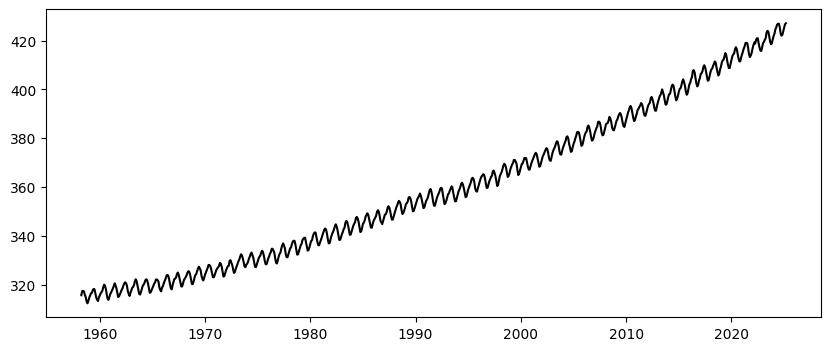

In [30]:
fig, ax = plt.subplots(figsize=(10,4)) #make axes (called ax) 10 units wide and 4 units high
ax.plot(time,df['average'],'k') #plot months vs. average on ax as a black ('k') line
#ax.set_xlabel('year') #text for the x-axis label
#ax.set_ylabel('average CO2 (ppm)') #text for the y-axis label
#ax.set_xlim([1958,2025]) #interval for the x-axis
#ax.set_ylim([300,450]) #interval for the y-axis
#ax.minorticks_on() #show the minor ticks

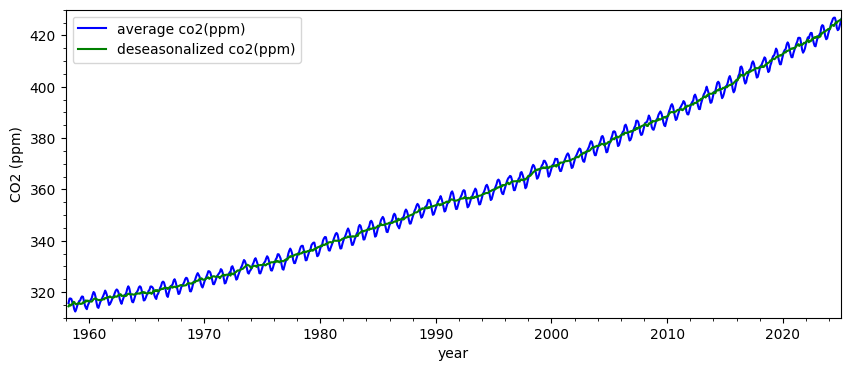

In [64]:
fig, ax = plt.subplots(figsize=(10,4)) #make axes (called ax) 10 units wide and 4 units high
ax.plot(time,df['average'],'b', label='average co2(ppm)') #plot time vs. average as a blue ('b') line, add label name for the line
ax.plot(time,df['deseasonalized'],'g', label='deseasonalized co2(ppm)') #plot time vs. deseasonalized as a green ('g') line
ax.set_xlabel('year') #text for the x-axis label
ax.set_ylabel('CO2 (ppm)') #text for the y-axis label
ax.set_xlim([1958,2025]) #interval for the x-axis
ax.set_ylim([310,430]) #interval for the y-axis
ax.minorticks_on() #show the minor ticks
ax.legend() #show the legend with the given labels above

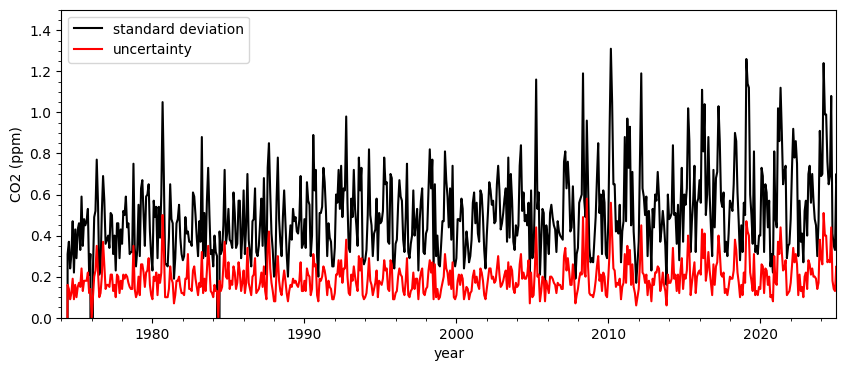

In [79]:
fig, ax = plt.subplots(figsize=(10,4)) #make axes (called ax) 10 units wide and 4 units high
ax.plot(time,df['sdev'],'k', label='standard deviation') #plot time vs. average as a black ('k') line, add label name for the line
ax.plot(time,df['unc'],'r', label='uncertainty') #plot time vs. deseasonalized as a red ('r') line
ax.set_xlabel('year') #text for the x-axis label
ax.set_ylabel('CO2 (ppm)') #text for the y-axis label
ax.set_xlim([1974,2025]) #interval for the x-axis
ax.set_ylim([0,1.5]) #interval for the y-axis
ax.minorticks_on() #show the minor ticks
ax.legend() #show the legend with the given labels above

Text(0.5, 0, 'year')

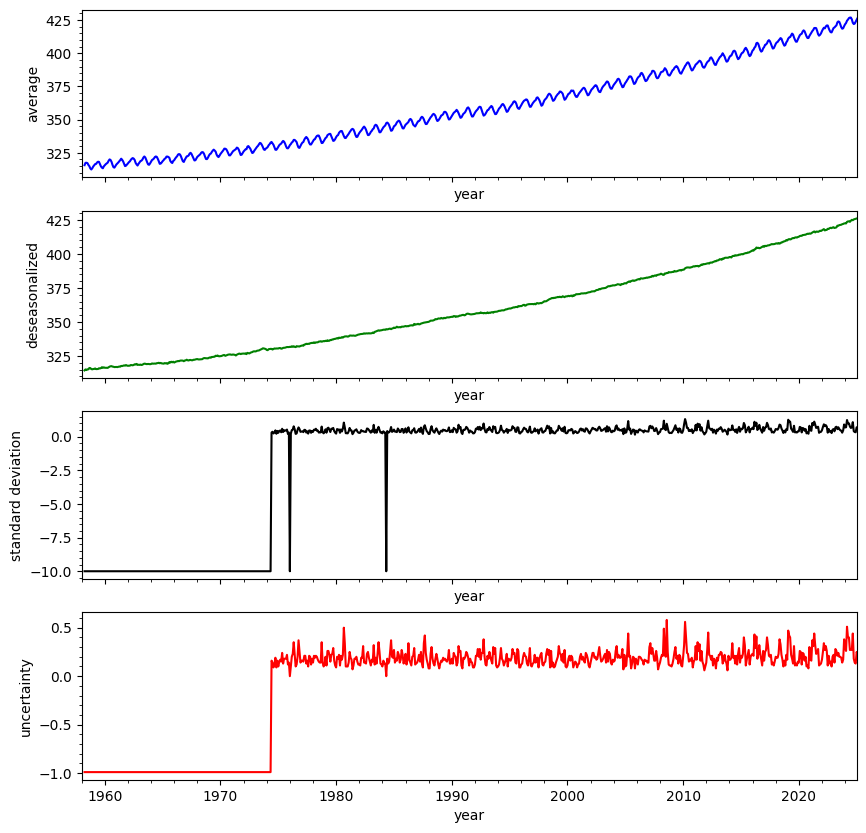

In [78]:
from datetime import timedelta
fig, ax = plt.subplots(4,1,figsize=(10, 10),sharex=True) #make 3 set axes in a column

ax[0].plot(time,df['average'],'b') #plot year vs.average in the first axes
ax[0].set_ylabel('average') #text for the y-axis label
ax[0].minorticks_on() #show the minor ticks

ax[1].plot(time,df['deseasonalized'],'g') #plot year vs. deseasonalized in the second axes
ax[1].set_ylabel('deseasonalized') #text for the y-axis label
ax[1].minorticks_on() #text for the y-axis label

ax[2].plot(time,df['sdev'],'k') #plot year vs. sdev in the second axes
ax[2].set_ylabel('standard deviation') #text for the y-axis label
ax[2].minorticks_on() #text for the y-axis label

ax[3].plot(time,df['unc'],'r') #plot year vs. unc in the second axes
ax[3].set_ylabel('uncertainty') #text for the y-axis label
ax[3].minorticks_on() #text for the y-axis label

ax[0].set_xlim([1958,2025]) #interval for the x-axis (will be the same for all axes)
ax[0].set_xlabel('year') #text for the x-axis label

ax[1].set_xlim([1958,2025]) #interval for the x-axis (will be the same for all axes)
ax[1].set_xlabel('year') #text for the x-axis label

ax[2].set_xlim([1958,2025]) #interval for the x-axis (will be the same for all axes)
ax[2].set_xlabel('year') #text for the x-axis label

ax[3].set_xlim([1958,2025]) #interval for the x-axis (will be the same for all axes)
ax[3].set_xlabel('year') #text for the x-axis label